# CH 4 - 21 : THE THREE DISTRIBUTIONS OF STATISTICAL INFERENCE

Ce cahier illustre les **trois distributions de l'inférence statistique** selon David Aronson :

1. **Distribution de population** : l'univers total des rendements possibles d'une règle de trading.
2. **Distribution de l'échantillon** : les rendements réellement observés dans ton backtest.
3. **Distribution d'échantillonnage** : la distribution des statistiques calculées, par exemple les moyennes de nombreux échantillons.

> Idée centrale : ton backtest n'est pas la vérité complète. C'est une petite fenêtre observable sur une réalité plus grande.  
> L'inférence statistique sert à relier ce passé connu au futur inconnu.

## Objectif du notebook

À la fin, tu dois sentir clairement la différence entre :

- **les rendements individuels** : les trades ou rendements quotidiens ;
- **la moyenne observée du backtest** : une seule statistique ;
- **toutes les moyennes possibles** : la distribution d'échantillonnage.

C'est cette dernière qui permet de répondre à la vraie question du trader :

> Est-ce que mon résultat de backtest est suffisamment exceptionnel pour penser qu'il ne vient pas seulement du hasard ?


## 1. La trinité statistique

Imagine que tu testes une stratégie de trading.

### A. Population : la vérité inconnue

La **population** représente tous les rendements que ta stratégie pourrait produire dans toutes les conditions possibles :

- passé non observé,
- futur proche,
- futurs scénarios de marché,
- régimes de volatilité différents.

En pratique, tu ne peux jamais voir cette distribution entièrement.

### B. Échantillon : ton backtest observable

L'**échantillon**, c'est ce que tu as vraiment :

- tes 300, 500 ou 2 000 rendements quotidiens ;
- les résultats réellement observés dans ton historique ;
- la seule chose finie, concrète, mesurable.

Mais attention : ce n'est qu'une réalisation possible.

### C. Distribution d'échantillonnage : le pont logique

La **distribution d'échantillonnage** n'est pas une distribution de rendements.

C'est une distribution de **statistiques calculées**.

Par exemple :

- moyenne du backtest 1 ;
- moyenne du backtest 2 ;
- moyenne du backtest 3 ;
- etc.

Elle répond à cette question :

> Si je pouvais refaire le même backtest des milliers de fois sur des échantillons différents de même taille, quelles moyennes pourrais-je obtenir par hasard ?


## 2. Le piège classique du trader

Un trader regarde souvent son backtest comme ceci :

> "J'ai fait +0.08 % par jour en moyenne, donc ma stratégie est bonne."

Mais cette conclusion est trop rapide.

Pourquoi ?

Parce que cette moyenne est calculée sur **un seul échantillon historique**.

La vraie question est :

> Est-ce que cette moyenne est rare ou banale par rapport à toutes les moyennes que le hasard aurait pu produire ?

C'est exactement le rôle de la distribution d'échantillonnage.

## Formule mentale simple

- **Population** = la vérité complète, mais invisible.
- **Échantillon** = ce que ton backtest montre.
- **Distribution d'échantillonnage** = ce que ton backtest aurait pu montrer si l'histoire avait été un peu différente.

EUREKA :

> Tu ne compares pas directement ton backtest au futur.  
> Tu compares ta statistique de backtest à un modèle de ce que le hasard peut produire.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Paramètres de simulation
# On imagine une stratégie avec un petit edge positif réel.
population_mean = 0.0004      # +0.04 % par jour
population_std = 0.01         # 1 % de volatilité quotidienne
population_size = 1_000_000   # population théorique très grande

# Taille du backtest observable
n_sample = 250  # environ 1 an de données quotidiennes

# Créons une population théorique de rendements quotidiens possibles
population_returns = np.random.normal(
    loc=population_mean,
    scale=population_std,
    size=population_size
)

# Tirons un seul échantillon : c'est ton backtest observable
sample_returns = np.random.choice(population_returns, size=n_sample, replace=False)

sample_mean = sample_returns.mean()
sample_std = sample_returns.std(ddof=1)

print(f"Moyenne vraie de la population : {population_mean:.5f}")
print(f"Moyenne observée du backtest   : {sample_mean:.5f}")
print(f"Écart-type observé du backtest : {sample_std:.5f}")


Moyenne vraie de la population : 0.00040
Moyenne observée du backtest   : -0.00076
Écart-type observé du backtest : 0.01015


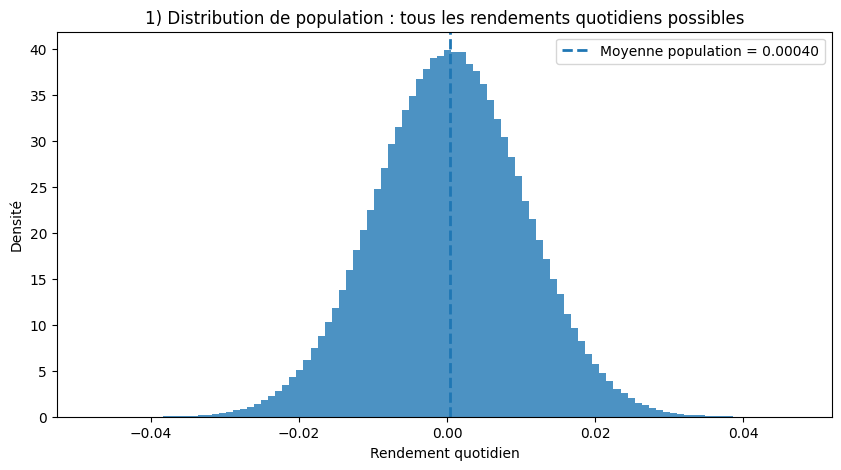

In [2]:
plt.figure(figsize=(10, 5))
plt.hist(population_returns, bins=100, density=True, alpha=0.8)
plt.axvline(population_mean, linestyle="--", linewidth=2, label=f"Moyenne population = {population_mean:.5f}")
plt.title("1) Distribution de population : tous les rendements quotidiens possibles")
plt.xlabel("Rendement quotidien")
plt.ylabel("Densité")
plt.legend()
plt.show()


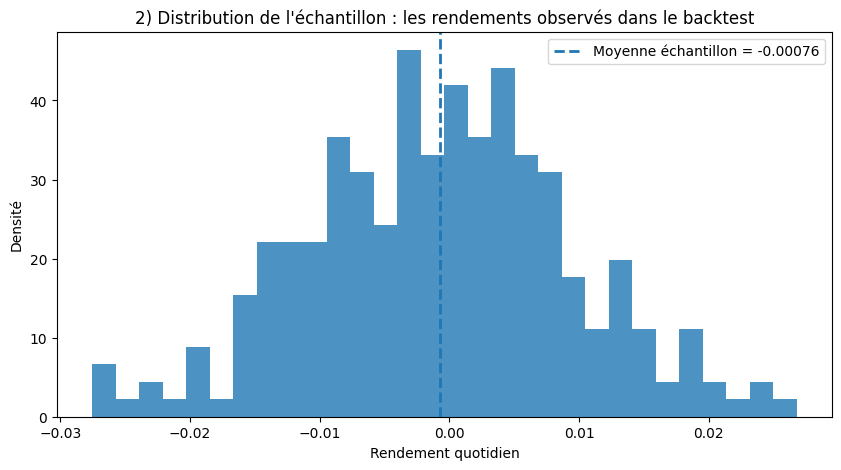

In [3]:
plt.figure(figsize=(10, 5))
plt.hist(sample_returns, bins=30, density=True, alpha=0.8)
plt.axvline(sample_mean, linestyle="--", linewidth=2, label=f"Moyenne échantillon = {sample_mean:.5f}")
plt.title("2) Distribution de l'échantillon : les rendements observés dans le backtest")
plt.xlabel("Rendement quotidien")
plt.ylabel("Densité")
plt.legend()
plt.show()


In [4]:
# Distribution d'échantillonnage :
# On répète l'expérience : tirer 250 rendements, calculer leur moyenne.
# Chaque moyenne représente un backtest possible.

n_experiments = 10_000
sample_means = []

for _ in range(n_experiments):
    simulated_sample = np.random.choice(population_returns, size=n_sample, replace=True)
    sample_means.append(simulated_sample.mean())

sample_means = np.array(sample_means)

print(f"Moyenne des moyennes simulées : {sample_means.mean():.5f}")
print(f"Écart-type des moyennes       : {sample_means.std(ddof=1):.5f}")
print(f"Erreur standard théorique     : {population_std / np.sqrt(n_sample):.5f}")


Moyenne des moyennes simulées : 0.00039
Écart-type des moyennes       : 0.00063
Erreur standard théorique     : 0.00063


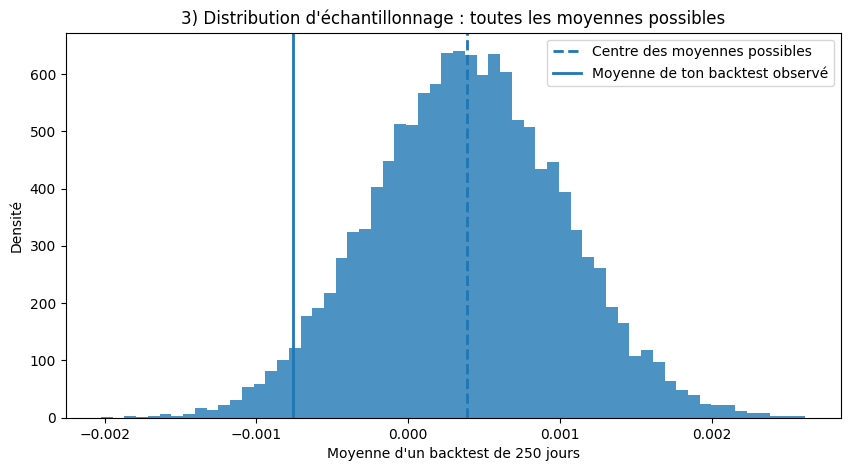

In [5]:
plt.figure(figsize=(10, 5))
plt.hist(sample_means, bins=60, density=True, alpha=0.8)
plt.axvline(sample_means.mean(), linestyle="--", linewidth=2, label="Centre des moyennes possibles")
plt.axvline(sample_mean, linestyle="-", linewidth=2, label="Moyenne de ton backtest observé")
plt.title("3) Distribution d'échantillonnage : toutes les moyennes possibles")
plt.xlabel("Moyenne d'un backtest de 250 jours")
plt.ylabel("Densité")
plt.legend()
plt.show()


## 3. Ce qu'il faut voir dans les graphiques

Les deux premiers graphiques montrent des **rendements individuels**.

Ils répondent à la question :

> À quoi ressemblent les jours/trades de la stratégie ?

Le troisième graphique montre des **moyennes de backtest**.

Il répond à une autre question :

> À quel point la moyenne observée de mon backtest est-elle normale ou exceptionnelle ?

C'est une différence énorme.

La volatilité des rendements individuels n'est pas la même chose que l'incertitude autour de la moyenne.

En trading :

- la distribution de l'échantillon montre le bruit quotidien ;
- la distribution d'échantillonnage montre l'incertitude sur la performance moyenne ;
- c'est cette incertitude qui sert aux tests d'hypothèse.


## 4. Version trading : modèle du hasard sous hypothèse nulle

Dans un test d'hypothèse, on simule souvent le monde où la stratégie n'a **aucun edge**.

Cela revient à dire :

> Hypothèse nulle : la moyenne vraie de la stratégie est égale à 0.

On va donc créer une population sans talent, centrée sur 0, puis regarder quelles moyennes de backtest le hasard peut produire.


In [6]:
# Population sous hypothèse nulle : stratégie sans edge
null_mean = 0.0
null_population = np.random.normal(
    loc=null_mean,
    scale=population_std,
    size=population_size
)

null_sample_means = []

for _ in range(n_experiments):
    simulated_sample = np.random.choice(null_population, size=n_sample, replace=True)
    null_sample_means.append(simulated_sample.mean())

null_sample_means = np.array(null_sample_means)

# p-value approximative : probabilité d'obtenir une moyenne au moins aussi grande
# que celle observée dans notre backtest, si la stratégie n'a aucun edge.
p_value = np.mean(null_sample_means >= sample_mean)

print(f"Moyenne observée du backtest : {sample_mean:.5f}")
print(f"p-value approximative        : {p_value:.4f}")


Moyenne observée du backtest : -0.00076
p-value approximative        : 0.8850


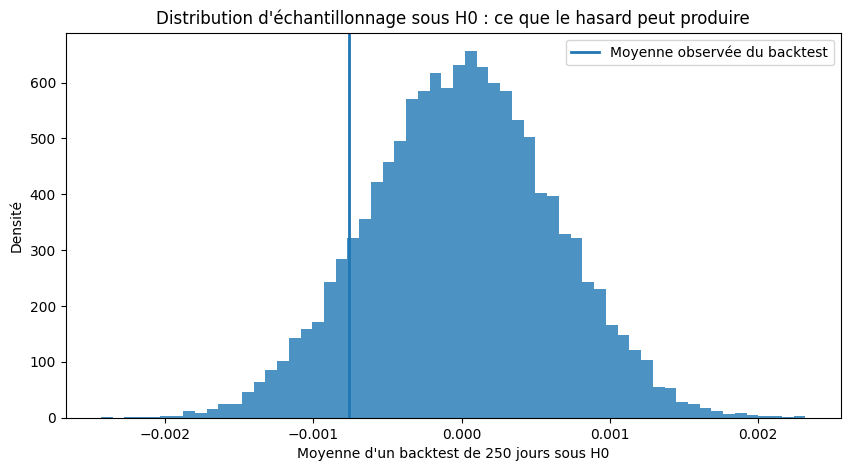

In [7]:
plt.figure(figsize=(10, 5))
plt.hist(null_sample_means, bins=60, density=True, alpha=0.8)
plt.axvline(sample_mean, linestyle="-", linewidth=2, label="Moyenne observée du backtest")
plt.title("Distribution d'échantillonnage sous H0 : ce que le hasard peut produire")
plt.xlabel("Moyenne d'un backtest de 250 jours sous H0")
plt.ylabel("Densité")
plt.legend()
plt.show()


## 5. Interprétation EBTA

Dans le dernier graphique, on voit le monde du hasard.

La distribution montre les moyennes que l'on peut obtenir avec une stratégie sans talent.

Si ta moyenne observée est très loin dans la queue droite, elle devient difficile à expliquer par le hasard seul.

C'est là que le raisonnement statistique commence :

> Plus le résultat observé est rare sous H0, plus on a de raisons de douter de H0.

Mais si ta moyenne observée tombe au milieu de ce que le hasard produit facilement, alors ton backtest n'est pas une preuve solide.

## Attention importante

Ce notebook utilise une simulation normale simple.

Dans un vrai backtest :

- les rendements peuvent ne pas être normalement distribués ;
- il peut y avoir de l'autocorrélation ;
- il peut y avoir des régimes de marché ;
- le data mining peut gonfler artificiellement les résultats ;
- il faut parfois utiliser bootstrap, White's Reality Check, ou d'autres méthodes robustes.

Mais la logique de base reste la même.


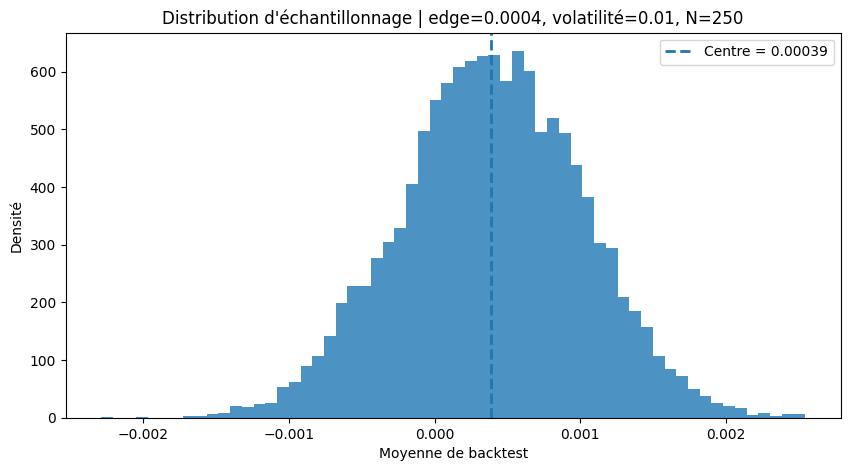

Moyenne des moyennes : 0.00039
Dispersion des moyennes : 0.00063


In [8]:
# Exercice : change ces paramètres et relance les cellules.
# Observe comment la distribution d'échantillonnage change.

def simulate_sampling_distribution(edge=0.0004, volatility=0.01, sample_size=250, n_runs=10000):
    population = np.random.normal(edge, volatility, 1_000_000)
    means = [
        np.random.choice(population, size=sample_size, replace=True).mean()
        for _ in range(n_runs)
    ]
    means = np.array(means)

    plt.figure(figsize=(10, 5))
    plt.hist(means, bins=60, density=True, alpha=0.8)
    plt.axvline(means.mean(), linestyle="--", linewidth=2, label=f"Centre = {means.mean():.5f}")
    plt.title(
        f"Distribution d'échantillonnage | edge={edge}, volatilité={volatility}, N={sample_size}"
    )
    plt.xlabel("Moyenne de backtest")
    plt.ylabel("Densité")
    plt.legend()
    plt.show()

    print(f"Moyenne des moyennes : {means.mean():.5f}")
    print(f"Dispersion des moyennes : {means.std(ddof=1):.5f}")

simulate_sampling_distribution(edge=0.0004, volatility=0.01, sample_size=250)


## 6. Résumé final

À retenir absolument :

| Concept | Contient quoi ? | Observable ? | Sert à quoi ? |
|---|---|---:|---|
| Population | Rendements individuels possibles | Non | Représente la vérité inconnue |
| Échantillon | Rendements individuels du backtest | Oui | Donne les données de départ |
| Distribution d'échantillonnage | Statistiques calculées, ex: moyennes | Non directement | Mesure ce que le hasard peut produire |

Phrase à graver :

> L'échantillon te montre ce qui s'est passé.  
> La distribution d'échantillonnage te montre ce qui aurait pu se passer.  
> La population représente ce que tu cherches réellement à connaître.

Pour un trader EBTA, cette distinction est fondamentale parce qu'elle empêche de confondre :

- un bon backtest ;
- une vraie preuve statistique ;
- une performance future probable.
